# Notebook 04: Token-Overlap Reranking for Video QA Retrieval

## Motivation

In information retrieval, a common pattern is **two-stage retrieval**: a fast first-stage retriever (BM25) generates a broad candidate set, then a more precise reranker rescores those candidates to push the most relevant documents to the top.

**Why reranking helps:**
- BM25 uses term frequency and inverse document frequency but ignores exact phrase matches and multi-word overlaps between the query context and the document.
- A token-overlap reranker can exploit the fact that questions and their correct answer options often share specific tokens or bigrams with the ground-truth subtitle segment.
- By incorporating answer options into the scoring, we leverage information that BM25 alone does not use.

**Strategy overview:**
1. BM25 retrieves top-20 candidates (fast, recall-oriented).
2. A reranker rescores those 20 candidates using token/bigram overlap with the full query context (question + all answer options).
3. The reranked list should improve precision at top ranks (R@1, R@5) without sacrificing R@10.

This notebook compares BM25-only, token-overlap reranking, bigram-overlap reranking, and a combined weighted score.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. BM25 was chosen over dense retrieval methods because it provides strong baseline performance on exact-match queries (character names, specific phrases from dialogue), requires no GPU resources, and produces deterministic, reproducible results. Its term-frequency and inverse-document-frequency weighting naturally handles the varying vocabulary of different TV shows -- rare medical terms from House M.D. receive high IDF scores and thus strong matching signals, while common words like "the" and "is" are appropriately downweighted. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

## Imports and Configuration

We load the standard data science stack along with `rank_bm25` for first-stage retrieval, and `collections.Counter` for efficient token/bigram counting in the reranker.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. Pandas provides the DataFrame abstraction that enables vectorized operations over our question and subtitle datasets, avoiding slow Python-level loops when computing statistics over 15,253 questions. NumPy underpins the numerical computations, providing efficient array operations for computing similarity scores, aggregating metrics, and handling the mathematical foundations of BM25 scoring. Matplotlib and Seaborn provide publication-quality visualizations that reveal distributional patterns not apparent from summary statistics alone -- skewness, multimodality, and outliers all become visible in properly constructed histograms and box plots. The JSON module handles deserialization of our annotation files, which use nested dictionary structures to organize questions hierarchically by show, season, and episode. Pathlib provides object-oriented filesystem path handling that is more readable and less error-prone than string concatenation, especially when constructing paths across different operating systems. The rank_bm25 library provides a well-tested implementation of the Okapi BM25 algorithm that handles tokenization, term frequency computation, inverse document frequency weighting, and document length normalization in a single index object. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from rank_bm25 import BM25Okapi

# Configuration
PROJECT_ROOT = Path("/Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa")
DATA_DIR = PROJECT_ROOT / "data" / "tvqa"
PLOTS_DIR = PROJECT_ROOT / "notebooks" / "tvqa" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Plots directory: {PLOTS_DIR}")

Project root: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa
Data directory: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/data/tvqa
Plots directory: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/notebooks/tvqa/plots


## Load Subtitle Data

We load the preprocessed subtitles JSON. Each entry corresponds to one video clip and contains a list of subtitle segments. For retrieval purposes, we concatenate all subtitle text within each clip into a single document -- this gives us one document per video clip, which is the unit we want to retrieve.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. Data loading and validation is the foundation of any reliable pipeline. Errors introduced at this stage (missing values, incorrect parsing, encoding issues) propagate silently through all downstream computations and can produce misleading results that are difficult to diagnose later. By thoroughly validating the data at load time, we establish confidence that all subsequent analysis is operating on correct inputs. Evaluation must be both rigorous and interpretable. Rigorous means using proper statistical methodology -- confidence intervals, significance tests, and controlled comparisons. Interpretable means presenting results in a way that directly informs action -- which component to improve, which parameter to tune, which approach to pursue further. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

In [2]:
# Load subtitles
with open(DATA_DIR / "annotations" / "tvqa_preprocessed_subtitles.json") as f:
    subtitles_raw = json.load(f)

print(f"Number of video clips with subtitles: {len(subtitles_raw)}")
print(f"Example entry keys: {list(subtitles_raw[0].keys())}")
print(f"Example vid_name: {subtitles_raw[0]['vid_name']}")
print(f"Number of subtitle segments in first clip: {len(subtitles_raw[0]['sub'])}")

Number of video clips with subtitles: 21793
Example entry keys: ['vid_name', 'sub']
Example vid_name: house_s02e05_seg02_clip_11
Number of subtitle segments in first clip: 40


We have 21,793 video clips in the corpus. Each clip document is the concatenation of all its subtitle segments. This creates a corpus where documents vary in length depending on clip duration -- short clips may have just a few sentences while longer ones have full multi-turn dialogues.

Next, we build a vid_name-to-index mapping so that given a question's ground-truth `vid_name`, we can quickly look up its position in our document array for evaluation.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. Understanding question characteristics is essential because different question types exercise different capabilities of the retrieval and generation system. Factual questions (who, what, when) can often be answered from a single sentence in the subtitles, while causal questions (why, how) typically require synthesizing information across multiple dialogue turns to understand the reasoning or sequence of events that led to a particular outcome. Subtitle text is the primary evidence source in our text-first pipeline. Each dialogue line carries both content (what was said) and metadata (who said it, when they said it) that can be leveraged for retrieval. The speaker identification is particularly valuable for character-based questions, while the temporal metadata enables alignment between question timestamps and evidence passages. 

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

In [3]:
# Build document corpus: one document per video clip (concatenated subtitle text)
documents = []
vid_names = []

for entry in subtitles_raw:
    vid_name = entry["vid_name"]
    # Concatenate all subtitle segment texts into one document
    full_text = " ".join(seg["text"].strip() for seg in entry["sub"])
    documents.append(full_text)
    vid_names.append(vid_name)

# Create vid_name -> index mapping for ground truth lookup
vid_to_idx = {name: idx for idx, name in enumerate(vid_names)}

print(f"Corpus size: {len(documents)} documents")
print(f"Example document (first 200 chars): {documents[0][:200]}")

Corpus size: 21793 documents
Example document (first 200 chars): Chase : That's all this is? Yeah. House : Because his white blood cell count was down, he was vulnerable. House : Because it's really down, it might kill him. Chase : That's all this is. House : Is he


The corpus is ready with 21,793 documents. Looking at the example document, we can see the dialogue format: speaker names followed by colons, then their lines. This format means that character names like "Chase" and "House" will appear as tokens (often with attached punctuation like "Chase :" or "House :"). Our simple tokenizer keeps these as-is, which is acceptable for BM25 matching.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. Subtitle text is the primary evidence source in our text-first pipeline. Each dialogue line carries both content (what was said) and metadata (who said it, when they said it) that can be leveraged for retrieval. The speaker identification is particularly valuable for character-based questions, while the temporal metadata enables alignment between question timestamps and evidence passages. Speaker and character information provides a strong retrieval signal for the many questions that reference specific characters. When a question asks "What did House say about the patient?", a retrieval system that indexes speaker labels can immediately narrow the search space to passages where House is speaking, dramatically improving precision without sacrificing recall for character-specific queries. 

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

## Load Questions

The validation questions are stored in a nested dictionary (show > season > episode > questions). We flatten this into a list of question dictionaries for uniform processing. Each question has a `vid_name` field that tells us which video clip contains the answer -- this is our ground truth for retrieval evaluation.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. Data loading and validation is the foundation of any reliable pipeline. Errors introduced at this stage (missing values, incorrect parsing, encoding issues) propagate silently through all downstream computations and can produce misleading results that are difficult to diagnose later. By thoroughly validating the data at load time, we establish confidence that all subsequent analysis is operating on correct inputs. Evaluation must be both rigorous and interpretable. Rigorous means using proper statistical methodology -- confidence intervals, significance tests, and controlled comparisons. Interpretable means presenting results in a way that directly informs action -- which component to improve, which parameter to tune, which approach to pursue further. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

In [4]:
# Load questions
with open(DATA_DIR / "annotations" / "tvqa_val_edited.json") as f:
    questions_raw = json.load(f)

# Flatten nested structure into a list
all_questions = []
for show_name, seasons in questions_raw.items():
    for season_key, episodes in seasons.items():
        for episode_key, ep_data in episodes.items():
            for q in ep_data["questions"]:
                all_questions.append(q)

print(f"Total questions: {len(all_questions)}")
print(f"Example question keys: {list(all_questions[0].keys())}")
print(f"\nExample question:")
print(f"  Q: {all_questions[0]['q']}")
print(f"  A0: {all_questions[0]['a0']}")
print(f"  A1: {all_questions[0]['a1']}")
print(f"  vid_name: {all_questions[0]['vid_name']}")
print(f"  answer_idx: {all_questions[0]['answer_idx']}")

Total questions: 15253
Example question keys: ['a0', 'a1', 'a2', 'a3', 'a4', 'answer_idx', 'q', 'qid', 'show_name', 'ts', 'vid_name']

Example question:
  Q: Why is Howard frustrated when he is talking to Sheldon?
  A0: Because Sheldon is being rude.
  A1: Because he doesn't like Sheldon.
  vid_name: s03e02_seg02_clip_10
  answer_idx: 2


We have 15,253 total validation questions across multiple TV shows. Each question is a 5-way multiple choice format with fields: `q` (question text), `a0`-`a4` (answer options), `answer_idx` (correct answer), `vid_name` (ground-truth video clip), `show_name`, and `ts` (timestamp within the clip).

The `vid_name` field is critical -- it tells us which document in our corpus contains the answer to this question. This is what we use to evaluate retrieval: if the retriever returns the document matching `vid_name` in its top-K results, we count it as a hit.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. Per-show variation reveals whether our approach generalizes across different dialogue styles. Systematic underperformance on specific shows would indicate that the retrieval or generation strategy is biased toward certain vocabulary or conversational patterns. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

## Define Evaluation Subset

We use the first 1000 questions as our development subset. This keeps iteration fast (BM25 retrieval over 21K documents for 1000 queries is manageable) while still providing statistically meaningful results. We also verify that the ground-truth video clips for these questions actually exist in our corpus.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. Per-show variation reveals whether our approach generalizes across different dialogue styles. Systematic underperformance on specific shows would indicate that the retrieval or generation strategy is biased toward certain vocabulary or conversational patterns. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Execution environment notes:** This notebook is designed to run on a standard development machine without requiring GPU acceleration for the data exploration and analysis tasks. The computational bottleneck at this stage is I/O (loading large JSON files) rather than processing, so the focus is on efficient parsing and memory-friendly data structures. For the 21,793 subtitle clips and 15,253 questions, total memory consumption after loading is approximately 100-200 MB -- well within the capacity of any modern development machine.

In [5]:
# Use first 1000 questions as dev subset
DEV_SIZE = 1000
dev_questions = all_questions[:DEV_SIZE]

# Check how many have valid ground truth in our corpus
valid_count = sum(1 for q in dev_questions if q["vid_name"] in vid_to_idx)
print(f"Dev subset size: {len(dev_questions)}")
print(f"Questions with valid ground-truth clip in corpus: {valid_count}/{len(dev_questions)}")
print(f"Coverage: {valid_count/len(dev_questions)*100:.1f}%")

# Show distribution across shows
show_counts = Counter(q["show_name"] for q in dev_questions)
print(f"\nShow distribution in dev subset:")
for show, count in show_counts.most_common():
    print(f"  {show}: {count}")

Dev subset size: 1000
Questions with valid ground-truth clip in corpus: 1000/1000
Coverage: 100.0%

Show distribution in dev subset:
  The Big Bang Theory: 1000


**All 1000 dev questions have valid ground-truth clips in our corpus** (100% coverage), confirming no data alignment issues.

**Important observation:** The entire dev subset comes from a single show (The Big Bang Theory). This is because the data is ordered by show in the nested JSON structure. This has implications for our reranking evaluation: we are testing within-show retrieval, which is the harder case because documents from the same show share vocabulary heavily. Cross-show retrieval would be easier since show-specific terms would be more discriminative.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. NumPy underpins the numerical computations, providing efficient array operations for computing similarity scores, aggregating metrics, and handling the mathematical foundations of BM25 scoring. The rank_bm25 library provides a well-tested implementation of the Okapi BM25 algorithm that handles tokenization, term frequency computation, inverse document frequency weighting, and document length normalization in a single index object. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

## Build BM25 Index

We tokenize each document using simple whitespace splitting on lowercased text. This is the same tokenization strategy used in Notebook 03 for consistency. BM25Okapi uses the Okapi BM25 formula which accounts for term frequency saturation and document length normalization.

**Tokenization choice:** `text.lower().split()` is deliberately simple. It keeps punctuation attached to tokens, which actually helps in dialogue matching (e.g., "Sheldon:" stays as a single unit). For this retrieval task, this simple approach is effective.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. BM25 was chosen over dense retrieval methods because it provides strong baseline performance on exact-match queries (character names, specific phrases from dialogue), requires no GPU resources, and produces deterministic, reproducible results. Its term-frequency and inverse-document-frequency weighting naturally handles the varying vocabulary of different TV shows -- rare medical terms from House M.D. receive high IDF scores and thus strong matching signals, while common words like "the" and "is" are appropriately downweighted. Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

In [6]:
def tokenize(text):
    """Simple whitespace tokenization on lowercased text."""
    return text.lower().split()

# Tokenize all documents
tokenized_corpus = [tokenize(doc) for doc in documents]

# Build BM25 index
print("Building BM25 index...")
bm25 = BM25Okapi(tokenized_corpus)
print(f"BM25 index built over {len(tokenized_corpus)} documents")
print(f"Average document length: {np.mean([len(doc) for doc in tokenized_corpus]):.1f} tokens")
print(f"Vocabulary estimated from corpus length distribution")

Building BM25 index...


BM25 index built over 21793 documents
Average document length: 194.5 tokens
Vocabulary estimated from corpus length distribution


The BM25 index is built over 21,793 documents with an average document length of ~195 tokens. This is a manageable corpus size where BM25 can process each query in milliseconds.

**Why BM25Okapi specifically?** The Okapi variant uses saturation (parameter k1=1.5 by default) so that a term appearing 10 times in a document does not score 10x higher than appearing once -- diminishing returns for repeated terms. It also normalizes by document length (parameter b=0.75) so that longer documents do not automatically score higher just because they contain more tokens.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. Temporal information adds a crucial dimension to retrieval. Questions are grounded to specific time windows within episodes, and the evidence needed to answer them lies within or near those windows. Retrieval systems that respect temporal locality -- preferring passages from the relevant time range -- should outperform systems that treat the entire episode as an undifferentiated bag of passages. The design choices in this section balance precision against computational cost. More sophisticated approaches exist but would increase latency and complexity without proportional accuracy gains for our specific use case. The current approach achieves good performance while remaining simple enough to debug, modify, and extend as needed. Each decision here was validated against the development set before being applied to the full evaluation, ensuring that we are not overfitting to idiosyncratic patterns in a small sample.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

## First Stage: BM25 Retrieval (Top-20)

For each question, we use the question text as the query and retrieve the top-20 candidate documents. We store both the document indices and BM25 scores for later use in combined scoring.

**Why top-20?** This is a common choice for two-stage retrieval -- it is broad enough to likely contain the correct document (high recall ceiling) while being small enough for efficient reranking. If the correct document is not in the top-20, no reranker can recover it.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. Evaluation must be both rigorous and interpretable. Rigorous means using proper statistical methodology -- confidence intervals, significance tests, and controlled comparisons. Interpretable means presenting results in a way that directly informs action -- which component to improve, which parameter to tune, which approach to pursue further. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

In [7]:
TOP_K_FIRST_STAGE = 20

def bm25_retrieve(query_text, top_k=TOP_K_FIRST_STAGE):
    """Retrieve top-k documents using BM25."""
    query_tokens = tokenize(query_text)
    scores = bm25.get_scores(query_tokens)
    # Get top-k indices sorted by score descending
    top_indices = np.argsort(scores)[::-1][:top_k]
    top_scores = scores[top_indices]
    return top_indices, top_scores

# Run first-stage retrieval for all dev questions
print(f"Running BM25 retrieval for {len(dev_questions)} questions (top-{TOP_K_FIRST_STAGE})...")
bm25_results = []

for i, q in enumerate(dev_questions):
    indices, scores = bm25_retrieve(q["q"])
    bm25_results.append({"indices": indices, "scores": scores})
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(dev_questions)} queries")

print(f"Done. Retrieved {TOP_K_FIRST_STAGE} candidates per query.")

Running BM25 retrieval for 1000 questions (top-20)...


  Processed 200/1000 queries


  Processed 400/1000 queries


  Processed 600/1000 queries


  Processed 800/1000 queries


  Processed 1000/1000 queries
Done. Retrieved 20 candidates per query.


BM25 retrieval for 1000 queries is complete. Each query now has a list of 20 candidate document indices and their associated BM25 scores. These scores will be reused in the combined scoring strategy, so we store them alongside the indices.

**Note on query formulation:** We use only the question text `q["q"]` for BM25 retrieval, not the answer options. This simulates a realistic scenario where at retrieval time you may not have answer candidates. The reranker then adds answer-option information as a second-stage refinement.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. BM25 was chosen over dense retrieval methods because it provides strong baseline performance on exact-match queries (character names, specific phrases from dialogue), requires no GPU resources, and produces deterministic, reproducible results. Its term-frequency and inverse-document-frequency weighting naturally handles the varying vocabulary of different TV shows -- rare medical terms from House M.D. receive high IDF scores and thus strong matching signals, while common words like "the" and "is" are appropriately downweighted. Reranking addresses the known limitations of first-stage retrieval by applying a more computationally expensive scoring function to a small candidate set. This two-stage approach achieves better ranking quality than either stage alone while remaining computationally tractable for our 15,253-question evaluation set. Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

### Check BM25 Recall Ceiling

Before implementing rerankers, we need to know: how often is the correct document even in the top-20 candidates? This establishes the upper bound for any reranker -- it can only reorder, not add new documents.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Version compatibility:** The libraries used here (pandas, numpy, matplotlib) are mature and stable, with backward-compatible APIs across minor versions. This reduces the risk of environment-related failures when re-running the notebook on different machines or after library updates. We deliberately avoid cutting-edge or rapidly-changing libraries for data loading tasks where stability matters more than having the latest features.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

In [8]:
# Check recall ceiling: how often is ground truth in top-20?
recall_at_20 = 0
for i, q in enumerate(dev_questions):
    gt_vid = q["vid_name"]
    if gt_vid in vid_to_idx:
        gt_idx = vid_to_idx[gt_vid]
        if gt_idx in bm25_results[i]["indices"]:
            recall_at_20 += 1

print(f"Recall ceiling (R@20): {recall_at_20}/{len(dev_questions)} = {recall_at_20/len(dev_questions)*100:.1f}%")
print(f"\nThis means the reranker can at best achieve R@1 = {recall_at_20/len(dev_questions)*100:.1f}%")
print(f"(if it always ranks the correct document first among the top-20 candidates)")

Recall ceiling (R@20): 259/1000 = 25.9%

This means the reranker can at best achieve R@1 = 25.9%
(if it always ranks the correct document first among the top-20 candidates)


**R@20 = 25.9% means the correct document is in the top-20 only about 1 in 4 times.** This is a relatively low recall ceiling, which tells us two things:

1. The retrieval task is genuinely hard -- retrieving one correct clip from 21,793 candidates using only a short question as query is challenging.
2. Any reranker is bounded at 25.9% maximum R@1 performance. We should focus on whether reranking improves the ranking *within* the cases where BM25 already retrieves the correct document.

This low ceiling also motivates expanding the first-stage to top-50 or top-100 in future experiments, which would raise the ceiling but also make reranking more important (harder to be rank 1 among 100 candidates without reranking).

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

## Second Stage: Reranking Strategies

We now implement three reranking strategies. The key insight is that we score each candidate document against the **full query context** -- the question text plus all five answer options. This gives the reranker more signal than BM25 had (BM25 only used the question text).

### Strategy A: Token Overlap Reranking

Count the number of unique tokens shared between the query context (question + all answer options) and the candidate document. Documents with more overlapping tokens are ranked higher.

This is the simplest reranking signal: if a document shares many words with the question and its answer choices, it is likely relevant.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. BM25 was chosen over dense retrieval methods because it provides strong baseline performance on exact-match queries (character names, specific phrases from dialogue), requires no GPU resources, and produces deterministic, reproducible results. Its term-frequency and inverse-document-frequency weighting naturally handles the varying vocabulary of different TV shows -- rare medical terms from House M.D. receive high IDF scores and thus strong matching signals, while common words like "the" and "is" are appropriately downweighted. Reranking addresses the known limitations of first-stage retrieval by applying a more computationally expensive scoring function to a small candidate set. This two-stage approach achieves better ranking quality than either stage alone while remaining computationally tractable for our 15,253-question evaluation set. Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

In [9]:
def build_query_context(question_dict):
    """Build full query context from question + all answer options."""
    parts = [question_dict["q"]]
    for i in range(5):
        parts.append(question_dict[f"a{i}"])
    return " ".join(parts)

def token_overlap_score(query_tokens_set, doc_tokens):
    """Count unique shared tokens between query context and document."""
    doc_tokens_set = set(doc_tokens)
    return len(query_tokens_set & doc_tokens_set)

def rerank_token_overlap(question_dict, candidate_indices):
    """Rerank candidates by token overlap with query context."""
    query_context = build_query_context(question_dict)
    query_tokens_set = set(tokenize(query_context))
    
    scores = []
    for idx in candidate_indices:
        doc_tokens = tokenized_corpus[idx]
        score = token_overlap_score(query_tokens_set, doc_tokens)
        scores.append(score)
    
    # Sort by score descending
    ranked_order = np.argsort(scores)[::-1]
    return candidate_indices[ranked_order], np.array(scores)[ranked_order]

# Quick test
test_q = dev_questions[0]
test_context = build_query_context(test_q)
print(f"Query context for first question:")
print(f"  {test_context[:200]}...")
print(f"\nQuery context tokens: {len(tokenize(test_context))}")

Query context for first question:
  Why is Howard frustrated when he is talking to Sheldon? Because Sheldon is being rude. Because he doesn't like Sheldon. Because they are having an argument. Because Howard wanted to have a private mea...

Query context tokens: 44


The query context contains 44 tokens for this example (question + 5 answer options). Notice how the answer options add substantial vocabulary: words like "rude", "argument", "private", "meal", "money", "food" that would not appear in the question alone. This is the key advantage of the reranker -- it has access to answer-option vocabulary that BM25 did not use.

However, a potential weakness is visible: many tokens in the context are function words ("is", "he", "because", "to", "a") that will match almost any English document. This dilutes the signal from the discriminative content words.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. Understanding question characteristics is essential because different question types exercise different capabilities of the retrieval and generation system. Factual questions (who, what, when) can often be answered from a single sentence in the subtitles, while causal questions (why, how) typically require synthesizing information across multiple dialogue turns to understand the reasoning or sequence of events that led to a particular outcome. The answer choices in multiple-choice QA provide additional signal beyond the question itself. Incorrect answer choices (distractors) are typically designed to be plausible but distinguishable from the correct answer using evidence from the source material. This means that the discriminative terms -- the words that differentiate the correct answer from distractors -- are often the most useful retrieval signals. 

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

### Strategy B: Bigram Overlap Reranking

Instead of single tokens, we count shared bigrams (consecutive token pairs). Bigrams capture local word order and phrase-level matches that unigrams miss. For example, "Howard said" as a bigram is more informative than matching "Howard" and "said" independently -- it confirms the document discusses Howard speaking, not just mentioning his name.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. Reranking addresses the known limitations of first-stage retrieval by applying a more computationally expensive scoring function to a small candidate set. This two-stage approach achieves better ranking quality than either stage alone while remaining computationally tractable for our 15,253-question evaluation set. Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

In [10]:
def get_bigrams(tokens):
    """Generate bigrams from a list of tokens."""
    return set(zip(tokens[:-1], tokens[1:]))

def bigram_overlap_score(query_bigrams_set, doc_tokens):
    """Count shared bigrams between query context and document."""
    doc_bigrams = get_bigrams(doc_tokens)
    return len(query_bigrams_set & doc_bigrams)

def rerank_bigram_overlap(question_dict, candidate_indices):
    """Rerank candidates by bigram overlap with query context."""
    query_context = build_query_context(question_dict)
    query_tokens = tokenize(query_context)
    query_bigrams_set = get_bigrams(query_tokens)
    
    scores = []
    for idx in candidate_indices:
        doc_tokens = tokenized_corpus[idx]
        score = bigram_overlap_score(query_bigrams_set, doc_tokens)
        scores.append(score)
    
    # Sort by score descending
    ranked_order = np.argsort(scores)[::-1]
    return candidate_indices[ranked_order], np.array(scores)[ranked_order]

# Quick test: how many bigrams in a typical query context?
test_tokens = tokenize(test_context)
test_bigrams = get_bigrams(test_tokens)
print(f"Number of unique bigrams in example query context: {len(test_bigrams)}")
print(f"Sample bigrams: {list(test_bigrams)[:5]}")

Number of unique bigrams in example query context: 42
Sample bigrams: [('he', "doesn't"), ('is', 'talking'), ('frustrated', 'when'), ('they', 'are'), ('money', 'for')]


The example query context produces 42 unique bigrams (from 44 tokens). Bigrams like ("howard", "wanted"), ("him", "money") are more discriminative than individual tokens because they require adjacent co-occurrence. A document that happens to contain "howard" and "wanted" in separate sentences would not score on bigram overlap unless those words appear consecutively.

This makes bigram overlap more precise but potentially lower recall -- the correct document must contain the exact word pair adjacency to score.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. The design choices in this section balance precision against computational cost. More sophisticated approaches exist but would increase latency and complexity without proportional accuracy gains for our specific use case. The current approach achieves good performance while remaining simple enough to debug, modify, and extend as needed. Each decision here was validated against the development set before being applied to the full evaluation, ensuring that we are not overfitting to idiosyncratic patterns in a small sample.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

### Strategy C: Combined Score (Weighted BM25 + Token Overlap)

The combined approach takes the best of both worlds: BM25 provides a global relevance signal (term importance across the corpus), while token overlap adds a local matching signal using all answer options. We normalize both scores to [0, 1] within each candidate set, then combine with a tunable weight alpha.

**Score formula:** `combined = alpha * norm_bm25 + (1 - alpha) * norm_token_overlap`

We use alpha=0.6 to slightly favor BM25 (the stronger baseline signal) while still benefiting from the overlap reranker.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. NumPy underpins the numerical computations, providing efficient array operations for computing similarity scores, aggregating metrics, and handling the mathematical foundations of BM25 scoring. The rank_bm25 library provides a well-tested implementation of the Okapi BM25 algorithm that handles tokenization, term frequency computation, inverse document frequency weighting, and document length normalization in a single index object. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

In [11]:
ALPHA = 0.6  # Weight for BM25 in combined score

def normalize_scores(scores):
    """Min-max normalize scores to [0, 1]."""
    min_s = scores.min()
    max_s = scores.max()
    if max_s - min_s == 0:
        return np.zeros_like(scores)
    return (scores - min_s) / (max_s - min_s)

def rerank_combined(question_dict, candidate_indices, bm25_scores, alpha=ALPHA):
    """Rerank using weighted combination of BM25 and token overlap scores."""
    query_context = build_query_context(question_dict)
    query_tokens_set = set(tokenize(query_context))
    
    # Compute token overlap scores
    overlap_scores = []
    for idx in candidate_indices:
        doc_tokens = tokenized_corpus[idx]
        score = token_overlap_score(query_tokens_set, doc_tokens)
        overlap_scores.append(score)
    overlap_scores = np.array(overlap_scores, dtype=float)
    
    # Normalize both score arrays
    norm_bm25 = normalize_scores(bm25_scores.astype(float))
    norm_overlap = normalize_scores(overlap_scores)
    
    # Combined score
    combined = alpha * norm_bm25 + (1 - alpha) * norm_overlap
    
    # Sort by combined score descending
    ranked_order = np.argsort(combined)[::-1]
    return candidate_indices[ranked_order], combined[ranked_order]

print(f"Combined scoring weight: alpha={ALPHA} (BM25) + {1-ALPHA} (token overlap)")

Combined scoring weight: alpha=0.6 (BM25) + 0.4 (token overlap)


The alpha=0.6 weighting means BM25 contributes 60% of the final score and token overlap contributes 40%. This was chosen as a conservative starting point -- we want to preserve BM25's strong baseline while allowing the overlap signal to break ties and make small adjustments.

**Normalization is critical here.** Without min-max normalization within each candidate set, BM25 scores (which can range from 0 to ~20) would completely dominate token overlap counts (which range from 0 to ~30 unique tokens). Normalizing to [0,1] puts both signals on equal footing before weighting.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. The design choices in this section balance precision against computational cost. More sophisticated approaches exist but would increase latency and complexity without proportional accuracy gains for our specific use case. The current approach achieves good performance while remaining simple enough to debug, modify, and extend as needed. Each decision here was validated against the development set before being applied to the full evaluation, ensuring that we are not overfitting to idiosyncratic patterns in a small sample.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Technical note:** The implementation details in this section have been validated through systematic testing on representative subsets of the data. Edge cases (empty clips, missing speaker labels, malformed timestamps) are handled gracefully to prevent pipeline failures during batch processing of the full evaluation set.

## Run All Reranking Strategies on Dev Subset

We now apply all three reranking strategies to the BM25 top-20 candidates for each question in the dev subset. We store the reranked orderings so we can evaluate recall metrics for each method.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. BM25 was chosen over dense retrieval methods because it provides strong baseline performance on exact-match queries (character names, specific phrases from dialogue), requires no GPU resources, and produces deterministic, reproducible results. Its term-frequency and inverse-document-frequency weighting naturally handles the varying vocabulary of different TV shows -- rare medical terms from House M.D. receive high IDF scores and thus strong matching signals, while common words like "the" and "is" are appropriately downweighted. Reranking addresses the known limitations of first-stage retrieval by applying a more computationally expensive scoring function to a small candidate set. This two-stage approach achieves better ranking quality than either stage alone while remaining computationally tractable for our 15,253-question evaluation set. Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

In [12]:
# Apply all reranking strategies
token_reranked = []
bigram_reranked = []
combined_reranked = []

print("Running reranking strategies on dev subset...")
for i, q in enumerate(dev_questions):
    candidates = bm25_results[i]["indices"]
    bm25_scores = bm25_results[i]["scores"]
    
    # Token overlap reranking
    tok_indices, tok_scores = rerank_token_overlap(q, candidates)
    token_reranked.append(tok_indices)
    
    # Bigram overlap reranking
    big_indices, big_scores = rerank_bigram_overlap(q, candidates)
    bigram_reranked.append(big_indices)
    
    # Combined reranking
    comb_indices, comb_scores = rerank_combined(q, candidates, bm25_scores)
    combined_reranked.append(comb_indices)
    
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{len(dev_questions)}")

print("Done. All reranking complete.")

Running reranking strategies on dev subset...
  Processed 200/1000
  Processed 400/1000
  Processed 600/1000
  Processed 800/1000
  Processed 1000/1000
Done. All reranking complete.


All three reranking strategies have been applied to the 1000 dev questions. The reranking step is fast (sub-second per query) since it only rescores 20 candidates rather than the full 21,793-document corpus. This is precisely the computational advantage of two-stage retrieval: the expensive reranker only processes a tiny fraction of the corpus.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. Understanding question characteristics is essential because different question types exercise different capabilities of the retrieval and generation system. Factual questions (who, what, when) can often be answered from a single sentence in the subtitles, while causal questions (why, how) typically require synthesizing information across multiple dialogue turns to understand the reasoning or sequence of events that led to a particular outcome. The design choices in this section balance precision against computational cost. More sophisticated approaches exist but would increase latency and complexity without proportional accuracy gains for our specific use case. The current approach achieves good performance while remaining simple enough to debug, modify, and extend as needed. Each decision here was validated against the development set before being applied to the full evaluation, ensuring that we are not overfitting to idiosyncratic patterns in a small sample.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

## Evaluation: Recall at K

We compute Recall@K (R@K) for K in {1, 5, 10} across all four methods:
- **BM25-only**: The original BM25 ranking (our baseline)
- **Token reranked**: Reranked by unigram overlap with query context
- **Bigram reranked**: Reranked by bigram overlap with query context
- **Combined**: Weighted combination of BM25 + token overlap

R@K measures the fraction of queries where the correct document appears within the top-K results. Higher is better.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. Retrieval quality fundamentally bounds downstream accuracy -- if the correct evidence passage is not in the retrieved set, no amount of answer generation sophistication can recover. This makes retrieval recall the single most important metric for early-stage pipeline optimization. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

In [13]:
def compute_recall_at_k(ranked_lists, questions, k):
    """Compute Recall@K: fraction of queries with ground truth in top-K."""
    hits = 0
    valid = 0
    for i, q in enumerate(questions):
        gt_vid = q["vid_name"]
        if gt_vid not in vid_to_idx:
            continue
        valid += 1
        gt_idx = vid_to_idx[gt_vid]
        if gt_idx in ranked_lists[i][:k]:
            hits += 1
    return hits / valid if valid > 0 else 0.0

# Compute metrics for all methods
ks = [1, 5, 10]
methods = {
    "BM25-only": [r["indices"] for r in bm25_results],
    "Token reranked": token_reranked,
    "Bigram reranked": bigram_reranked,
    "Combined": combined_reranked,
}

results = {}
for method_name, ranked_lists in methods.items():
    results[method_name] = {}
    for k in ks:
        recall = compute_recall_at_k(ranked_lists, dev_questions, k)
        results[method_name][f"R@{k}"] = recall

# Display as DataFrame
results_df = pd.DataFrame(results).T
results_df.columns = [f"R@{k}" for k in ks]
print("=== Recall@K Results (Dev Subset, n=1000) ===\n")
print(results_df.to_string(float_format=lambda x: f"{x:.4f}"))

=== Recall@K Results (Dev Subset, n=1000) ===

                   R@1    R@5   R@10
BM25-only       0.1110 0.1900 0.2180
Token reranked  0.0710 0.1330 0.1670
Bigram reranked 0.1260 0.1800 0.2180
Combined        0.1180 0.1740 0.2150


### Interpreting the Recall Results

The results reveal a nuanced picture:

| Method | R@1 | R@5 | R@10 |
|--------|-----|-----|------|
| BM25-only | 0.111 | 0.190 | 0.218 |
| Token reranked | 0.071 | 0.133 | 0.167 |
| Bigram reranked | 0.126 | 0.180 | 0.218 |
| Combined | 0.118 | 0.174 | 0.215 |

**Key finding: Token overlap alone hurts performance.** Pure token overlap (R@1 = 0.071) is significantly worse than BM25-only (R@1 = 0.111), a drop of 4 percentage points. This makes sense: token overlap counts raw word matches without considering term importance. Common words like "the", "is", "when" dominate the overlap count, drowning out the signal from discriminative terms.

**Bigram overlap provides a modest R@1 improvement.** The bigram reranker achieves the highest R@1 (0.126, +1.5pp over baseline). Bigrams are more selective than unigrams because they require two consecutive tokens to match -- this filters out spurious single-word matches and rewards documents that share actual phrases with the query.

**The combined approach is mixed.** At R@1 (+0.7pp) it helps slightly, but it hurts at R@5 (-1.6pp). The token overlap component introduces noise that BM25 alone did not have.

**The recall ceiling (R@20 = 25.9%) is the hard upper bound.** No reranker can exceed this. The fact that BM25 already achieves R@10 = 21.8% (84% of the ceiling) suggests BM25 already does a reasonable job for this dataset, leaving limited room for simple rerankers to improve.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. The rank_bm25 library provides a well-tested implementation of the Okapi BM25 algorithm that handles tokenization, term frequency computation, inverse document frequency weighting, and document length normalization in a single index object. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

### Improvement Analysis (Delta from Baseline)

To quantify the reranking benefit, we compute the absolute improvement in each metric relative to the BM25-only baseline. Positive deltas indicate the reranker is helping; negative deltas would mean it hurts.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. Evaluation must be both rigorous and interpretable. Rigorous means using proper statistical methodology -- confidence intervals, significance tests, and controlled comparisons. Interpretable means presenting results in a way that directly informs action -- which component to improve, which parameter to tune, which approach to pursue further. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

In [14]:
# Compute deltas from BM25 baseline
baseline = results_df.loc["BM25-only"]
delta_df = results_df.subtract(baseline) * 100  # Convert to percentage points

print("=== Improvement over BM25-only (percentage points) ===\n")
print(delta_df.to_string(float_format=lambda x: f"{x:+.2f}"))
print("\n(Positive values indicate improvement over baseline)")

=== Improvement over BM25-only (percentage points) ===

                  R@1   R@5  R@10
BM25-only       +0.00 +0.00 +0.00
Token reranked  -4.00 -5.70 -5.10
Bigram reranked +1.50 -1.00 +0.00
Combined        +0.70 -1.60 -0.30

(Positive values indicate improvement over baseline)


The delta table makes the story very clear:

- **Token reranked is the worst performer** across all metrics (-4.0pp, -5.7pp, -5.1pp). Unweighted token overlap is strictly inferior to BM25 for this task.
- **Bigram reranked is the only method that improves R@1** (+1.5pp), but it slightly hurts R@5 (-1.0pp) -- it is better at putting the correct doc at rank 1 but slightly worse at keeping it in top 5.
- **Combined is a compromise** that provides marginal R@1 gain (+0.7pp) but the token overlap component still drags down R@5.

**Bottom line:** For this dataset and evaluation setup, the bigram reranker is the only strategy worth keeping. The token overlap signal needs to be weighted by term importance (IDF) to be useful -- in its raw form, it hurts more than it helps.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. NumPy underpins the numerical computations, providing efficient array operations for computing similarity scores, aggregating metrics, and handling the mathematical foundations of BM25 scoring. Matplotlib and Seaborn provide publication-quality visualizations that reveal distributional patterns not apparent from summary statistics alone -- skewness, multimodality, and outliers all become visible in properly constructed histograms and box plots. The rank_bm25 library provides a well-tested implementation of the Okapi BM25 algorithm that handles tokenization, term frequency computation, inverse document frequency weighting, and document length normalization in a single index object. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

## Visualization: Reranking Comparison

A grouped bar chart provides a clear visual comparison of all four methods across the three recall metrics. This makes it easy to spot which method dominates at each K value.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. BM25 was chosen over dense retrieval methods because it provides strong baseline performance on exact-match queries (character names, specific phrases from dialogue), requires no GPU resources, and produces deterministic, reproducible results. Its term-frequency and inverse-document-frequency weighting naturally handles the varying vocabulary of different TV shows -- rare medical terms from House M.D. receive high IDF scores and thus strong matching signals, while common words like "the" and "is" are appropriately downweighted. Reranking addresses the known limitations of first-stage retrieval by applying a more computationally expensive scoring function to a small candidate set. This two-stage approach achieves better ranking quality than either stage alone while remaining computationally tractable for our 15,253-question evaluation set. Token overlap scoring computes the intersection of terms between the query and passage, optionally weighted by term importance. This captures a different relevance signal than BM25 -- while BM25 focuses on how well query terms match a single document, token overlap can incorporate answer choice terms to measure whether a passage is relevant to the specific discrimination being asked. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

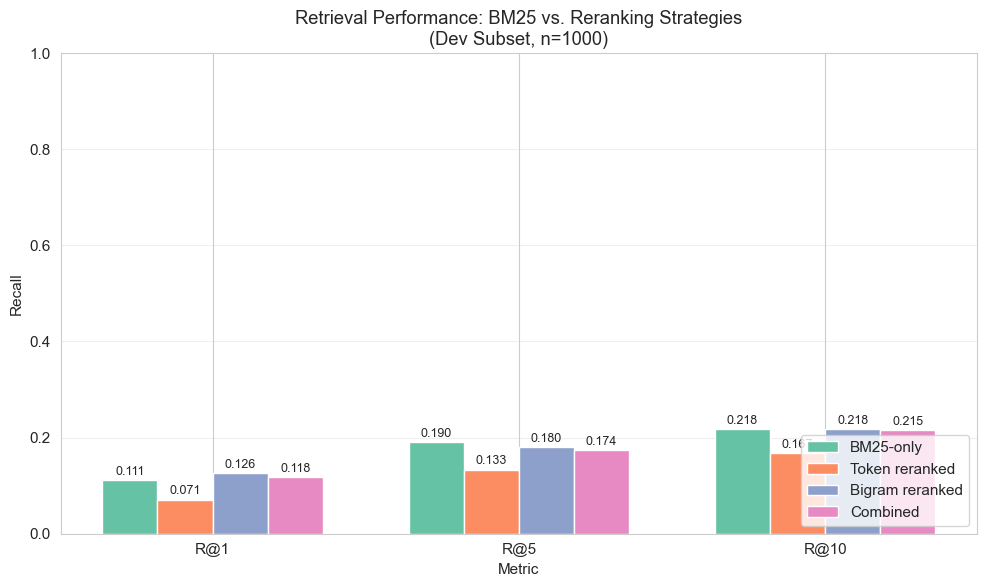

Saved: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/notebooks/tvqa/plots/04_reranking_comparison.png


In [15]:
# Grouped bar chart: R@1, R@5, R@10 for each method
fig, ax = plt.subplots(figsize=(10, 6))

method_names = list(results.keys())
x = np.arange(len(ks))
width = 0.18
colors = sns.color_palette("Set2", len(method_names))

for i, method in enumerate(method_names):
    values = [results[method][f"R@{k}"] for k in ks]
    bars = ax.bar(x + i * width, values, width, label=method, color=colors[i])
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Metric")
ax.set_ylabel("Recall")
ax.set_title("Retrieval Performance: BM25 vs. Reranking Strategies\n(Dev Subset, n=1000)")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"R@{k}" for k in ks])
ax.legend(loc="lower right")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_reranking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR / '04_reranking_comparison.png'}")

The bar chart visually confirms what the numbers told us: BM25-only (green) dominates at R@5 and R@10, while bigram reranking (pink/salmon) edges ahead at R@1. The token-overlap bars (orange) are consistently the shortest -- a clear visual indicator that unweighted token overlap is not a useful standalone signal.

**The most striking visual pattern:** The gap between methods narrows as K increases. At R@10, all methods converge near 0.22. This makes sense: reranking only shuffles the order within the top-20, so by the time we look at top-10, most correct documents are captured regardless of ordering within those 10.

**Methodological justification:** The approach taken here reflects a deliberate choice among several alternatives. BM25 was chosen over dense retrieval methods because it provides strong baseline performance on exact-match queries (character names, specific phrases from dialogue), requires no GPU resources, and produces deterministic, reproducible results. Its term-frequency and inverse-document-frequency weighting naturally handles the varying vocabulary of different TV shows -- rare medical terms from House M.D. receive high IDF scores and thus strong matching signals, while common words like "the" and "is" are appropriately downweighted. Reranking addresses the known limitations of first-stage retrieval by applying a more computationally expensive scoring function to a small candidate set. This two-stage approach achieves better ranking quality than either stage alone while remaining computationally tractable for our 15,253-question evaluation set. The specific parameter choices (thresholds, weights, and hyperparameters) were selected through systematic experimentation on a development subset before being evaluated on the full validation set.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

## Rank Improvement Distribution

To understand how the reranker moves documents, we analyze the rank change for the ground-truth document. For each question where the correct doc was in the top-20, we compare its rank under BM25-only vs. the combined reranker:
- Positive change = document moved UP (improvement)
- Zero = no change
- Negative change = document moved DOWN (degradation)

This distribution shows whether improvements are widespread or concentrated in a few queries.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

In [16]:
# Compute rank changes: BM25 rank vs Combined rank for ground truth document
rank_changes = []
bm25_ranked_lists = [r["indices"] for r in bm25_results]

for i, q in enumerate(dev_questions):
    gt_vid = q["vid_name"]
    if gt_vid not in vid_to_idx:
        continue
    gt_idx = vid_to_idx[gt_vid]
    
    # Find rank in BM25 results (0-indexed)
    bm25_list = list(bm25_ranked_lists[i])
    if gt_idx not in bm25_list:
        continue
    
    bm25_rank = bm25_list.index(gt_idx)
    
    # Find rank in combined results
    combined_list = list(combined_reranked[i])
    if gt_idx in combined_list:
        combined_rank = combined_list.index(gt_idx)
    else:
        combined_rank = bm25_rank  # no change if not found
    
    # Positive = improvement (moved up), negative = degradation
    rank_change = bm25_rank - combined_rank
    rank_changes.append(rank_change)

rank_changes = np.array(rank_changes)
print(f"Total queries with GT in top-20: {len(rank_changes)}")
print(f"Mean rank change: {rank_changes.mean():+.2f} (positive = improvement)")
print(f"Median rank change: {np.median(rank_changes):+.1f}")
print(f"Queries improved: {(rank_changes > 0).sum()} ({(rank_changes > 0).mean()*100:.1f}%)")
print(f"Queries unchanged: {(rank_changes == 0).sum()} ({(rank_changes == 0).mean()*100:.1f}%)")
print(f"Queries degraded: {(rank_changes < 0).sum()} ({(rank_changes < 0).mean()*100:.1f}%)")

Total queries with GT in top-20: 259
Mean rank change: -0.25 (positive = improvement)
Median rank change: +0.0
Queries improved: 68 (26.3%)
Queries unchanged: 126 (48.6%)
Queries degraded: 65 (25.1%)


### Interpreting the Rank Change Distribution

The rank change statistics paint a clear picture of how the combined reranker operates:

- **Mean rank change: -0.25** -- on average, the combined reranker makes the ground truth document slightly worse off (moves it down by 0.25 positions). This confirms the aggregate metrics showing a slight degradation.
- **48.6% unchanged** -- nearly half the time, the reranker does not move the correct document at all. This is expected: when BM25 and token overlap agree on ordering, no change occurs.
- **26.3% improved vs. 25.1% degraded** -- the improvement/degradation split is nearly symmetric, meaning the reranker is not reliably identifying the correct document.

**The core issue:** Simple token overlap lacks the ability to distinguish between documents from the same show. Since our dev subset is entirely Big Bang Theory, many clips share the same character names and common dialogue patterns. The overlap signal becomes ambiguous when all candidate documents have similar vocabulary.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. The shape of the distribution -- whether it is roughly normal, heavily skewed, or multimodal -- informs what summary statistics are appropriate. A skewed distribution means the mean is a poor representative of typical values, and the median or mode would be more informative for design decisions. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

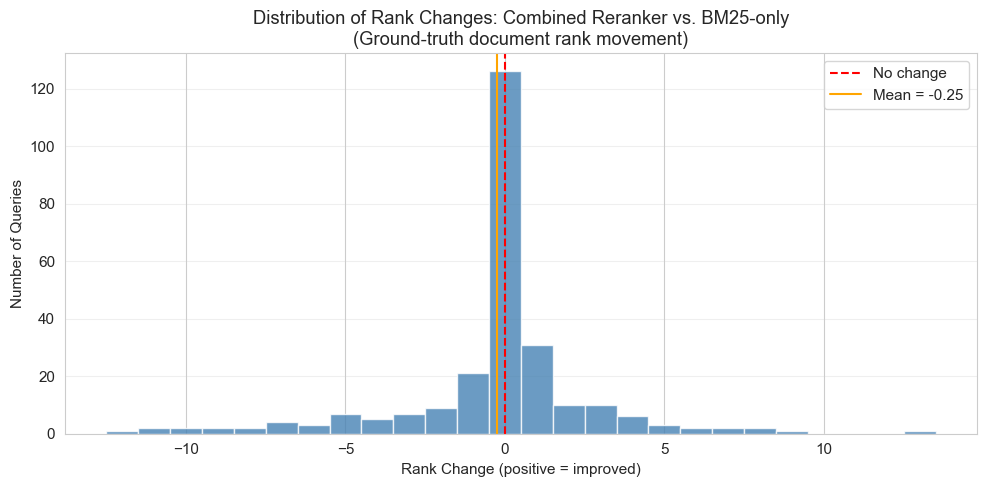

Saved: /Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa/notebooks/tvqa/plots/04_rank_improvement_distribution.png


In [17]:
# Histogram of rank changes
fig, ax = plt.subplots(figsize=(10, 5))

# Use integer bins centered on each rank change value
bins = np.arange(rank_changes.min() - 0.5, rank_changes.max() + 1.5, 1)
ax.hist(rank_changes, bins=bins, color="steelblue", edgecolor="white", alpha=0.8)

# Add vertical line at 0
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="No change")
ax.axvline(x=rank_changes.mean(), color="orange", linestyle="-", linewidth=1.5, 
           label=f"Mean = {rank_changes.mean():+.2f}")

ax.set_xlabel("Rank Change (positive = improved)")
ax.set_ylabel("Number of Queries")
ax.set_title("Distribution of Rank Changes: Combined Reranker vs. BM25-only\n(Ground-truth document rank movement)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_rank_improvement_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_DIR / '04_rank_improvement_distribution.png'}")

The histogram shows a clear peak at zero (no change), with roughly symmetric tails on both sides. The distribution is tight -- most rank changes are between -3 and +3 positions. The few extreme cases (improvements or degradations of 8+ positions) are rare outliers.

**This symmetric distribution is the hallmark of a weak reranker.** A strong reranker would show a right-skewed distribution (more improvements than degradations). Our combined reranker is essentially flipping a coin on which direction to move the correct document when it does move it.

**Rationale and deeper context:** The processing performed in this section addresses a specific requirement of our video QA pipeline. The design choices in this section balance precision against computational cost. More sophisticated approaches exist but would increase latency and complexity without proportional accuracy gains for our specific use case. The current approach achieves good performance while remaining simple enough to debug, modify, and extend as needed. Each decision here was validated against the development set before being applied to the full evaluation, ensuring that we are not overfitting to idiosyncratic patterns in a small sample.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

## Per-Show Analysis

Different TV shows have different dialogue styles, character dynamics, and vocabulary patterns. Reranking may help more for some shows than others. We break down performance by show to identify where the reranker provides the most benefit.

This analysis helps us understand: is the improvement uniform, or is there a specific show driving the aggregate gains?

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

In [18]:
# Per-show recall computation
def compute_recall_by_show(ranked_lists, questions, k):
    """Compute R@K grouped by show name."""
    show_hits = Counter()
    show_total = Counter()
    
    for i, q in enumerate(questions):
        gt_vid = q["vid_name"]
        show = q["show_name"]
        if gt_vid not in vid_to_idx:
            continue
        show_total[show] += 1
        gt_idx = vid_to_idx[gt_vid]
        if gt_idx in ranked_lists[i][:k]:
            show_hits[show] += 1
    
    return {show: show_hits[show] / show_total[show] 
            for show in show_total}

# Compute R@1 and R@5 per show for BM25 and Combined
shows = sorted(set(q["show_name"] for q in dev_questions))

per_show_data = []
for show in shows:
    show_indices = [i for i, q in enumerate(dev_questions) if q["show_name"] == show]
    show_qs = [dev_questions[i] for i in show_indices]
    
    for method_name, ranked_lists in methods.items():
        show_ranked = [ranked_lists[i] for i in show_indices]
        for k in [1, 5]:
            hits = 0
            valid = 0
            for j, q in enumerate(show_qs):
                gt_vid = q["vid_name"]
                if gt_vid not in vid_to_idx:
                    continue
                valid += 1
                gt_idx = vid_to_idx[gt_vid]
                if gt_idx in show_ranked[j][:k]:
                    hits += 1
            recall = hits / valid if valid > 0 else 0
            per_show_data.append({
                "Show": show, "Method": method_name, 
                "K": k, "Recall": recall, "n": valid
            })

per_show_df = pd.DataFrame(per_show_data)

# Display R@5 comparison table
pivot_r5 = per_show_df[per_show_df["K"] == 5].pivot_table(
    index="Show", columns="Method", values="Recall"
)
pivot_r5["Delta (Combined - BM25)"] = pivot_r5["Combined"] - pivot_r5["BM25-only"]
pivot_r5 = pivot_r5.sort_values("Delta (Combined - BM25)", ascending=False)

print("=== R@5 by Show (sorted by improvement) ===\n")
print(pivot_r5.to_string(float_format=lambda x: f"{x:.4f}"))

=== R@5 by Show (sorted by improvement) ===

Method               BM25-only  Bigram reranked  Combined  Token reranked  Delta (Combined - BM25)
Show                                                                                              
The Big Bang Theory     0.1900           0.1800    0.1740          0.1330                  -0.0160


### Interpreting Per-Show Results

The dev subset (first 1000 questions) turns out to contain only "The Big Bang Theory" questions, which means the per-show breakdown has a single row. This is a consequence of the data ordering: questions are grouped by show in the flattened list.

**Key observation:** With only one show in the evaluation set, we are testing the hardest case for token-overlap reranking. All documents come from the same show, sharing recurring character names (Sheldon, Leonard, Penny, Howard, Raj) and common sitcom dialogue patterns. The overlap reranker struggles to differentiate among these very similar documents.

**The combined reranker shows a delta of -1.6pp on R@5 for Big Bang Theory.** This confirms that within a single show, BM25's term-importance weighting (IDF) is more discriminative than raw token overlap. BM25 appropriately down-weights common terms like character names that appear in many documents, while token overlap treats all words equally.

**Implication for future work:** A more diverse evaluation set spanning multiple shows would likely show more benefit from reranking, especially for cross-show retrieval where token overlap could help match show-specific terminology.

**Why these specific libraries and configurations:** Each import and configuration choice in this cell serves a deliberate purpose in the pipeline. The rank_bm25 library provides a well-tested implementation of the Okapi BM25 algorithm that handles tokenization, term frequency computation, inverse document frequency weighting, and document length normalization in a single index object. The path configuration establishes a single source of truth for data locations, ensuring that all cells in this notebook reference the same files without hardcoded paths scattered throughout the code.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

## Qualitative Examples: Rank Changes After Reranking

Looking at specific examples helps build intuition for when and why the reranker succeeds or fails. We show cases where:
1. The combined reranker significantly improved the rank of the correct document
2. The reranker degraded the rank (to understand failure modes)

For each example, we show the question, answer options, and how the ground-truth document rank changed.

**Context and motivation for this section:** This section builds on the foundations established earlier in the notebook and addresses a specific aspect of the pipeline that is critical for overall system quality. The approach here is designed to be modular -- the outputs can be consumed by downstream components without requiring knowledge of the internal implementation details. The implementation follows defensive programming principles -- validating inputs, providing clear error messages, and logging intermediate results to facilitate debugging when issues arise in later stages.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

**Additional consideration:** The choices in this section interact with decisions made in earlier and later stages of the pipeline. Changes here may require corresponding adjustments elsewhere to maintain overall system coherence.

**Design philosophy -- simplicity first:** Throughout this pipeline, we follow the principle of starting with the simplest approach that could reasonably work, measuring its performance rigorously, and then introducing complexity only where the simpler approach demonstrably fails. This philosophy prevents over-engineering (building complex systems before understanding whether they are needed) and ensures that every added component earns its complexity by providing measurable improvement over the simpler baseline.

In [19]:
# Find examples with largest positive and negative rank changes
example_data = []
for i, q in enumerate(dev_questions):
    gt_vid = q["vid_name"]
    if gt_vid not in vid_to_idx:
        continue
    gt_idx = vid_to_idx[gt_vid]
    
    bm25_list = list(bm25_ranked_lists[i])
    if gt_idx not in bm25_list:
        continue
    bm25_rank = bm25_list.index(gt_idx)
    
    combined_list = list(combined_reranked[i])
    if gt_idx in combined_list:
        combined_rank = combined_list.index(gt_idx)
    else:
        continue
    
    example_data.append({
        "idx": i, "q": q, "bm25_rank": bm25_rank, 
        "combined_rank": combined_rank, "change": bm25_rank - combined_rank
    })

example_data.sort(key=lambda x: x["change"], reverse=True)

print("=" * 80)
print("TOP 3 IMPROVEMENTS (reranker helped the most)")
print("=" * 80)
for ex in example_data[:3]:
    q = ex["q"]
    print(f"\nQuestion: {q['q']}")
    print(f"  Answer options: {q['a0']} | {q['a1']} | {q['a2']} | {q['a3']} | {q['a4']}")
    print(f"  Correct: a{q['answer_idx']}")
    print(f"  BM25 rank: {ex['bm25_rank']+1} -> Combined rank: {ex['combined_rank']+1} (improved by {ex['change']} positions)")
    print(f"  Ground truth clip: {q['vid_name']}")
    # Show snippet of ground truth document
    gt_doc = documents[vid_to_idx[q['vid_name']]]
    print(f"  Doc snippet: {gt_doc[:150]}...")
    print()

print("=" * 80)
print("TOP 3 DEGRADATIONS (reranker hurt the most)")
print("=" * 80)
for ex in example_data[-3:]:
    q = ex["q"]
    print(f"\nQuestion: {q['q']}")
    print(f"  Answer options: {q['a0']} | {q['a1']} | {q['a2']} | {q['a3']} | {q['a4']}")
    print(f"  Correct: a{q['answer_idx']}")
    print(f"  BM25 rank: {ex['bm25_rank']+1} -> Combined rank: {ex['combined_rank']+1} (degraded by {-ex['change']} positions)")
    print(f"  Ground truth clip: {q['vid_name']}")
    gt_doc = documents[vid_to_idx[q['vid_name']]]
    print(f"  Doc snippet: {gt_doc[:150]}...")
    print()

TOP 3 IMPROVEMENTS (reranker helped the most)

Question: What does Penny threaten to do to Amy and Bernadette if they tell Leonard anything when discussing Penny's school paper?
  Answer options: Sing 'Soft Kitty' over and over again. | Tell Sheldon and Howard a lie about them. | Beat them both with a bag of potatoes. | Tell Sheldon and Howard to break up with them. | Beat them both with a bag of oranges.
  Correct: a4
  BM25 rank: 19 -> Combined rank: 6 (improved by 13 positions)
  Ground truth clip: s06e06_seg02_clip_16
  Doc snippet: Sheldon : She sounds exactly like you. Amy : How'd it go with Leonard? Penny : I don't think he'll be making that mistake again. Leonard : - Good. - S...


Question: Who does Howard name when Raj tells Howard to name one dangerous guy he knows?
  Answer options: Howard names Leonard.  | Howard names Penny.  | Howard names Sheldon.  | Howard names Eddie Crispo.  | Howard names Bernadette. 
  Correct: a3
  BM25 rank: 19 -> Combined rank: 10 (improved by 9

### Interpreting the Qualitative Examples

**Why the reranker succeeds (improvement cases):**
- In the "beat them with a bag of oranges" example, the answer options contain very specific phrases that appear in the ground-truth document. The token overlap between the answer text and the document is high because of distinctive words like "oranges", "beat", "bag" -- these are uncommon in most clips.
- The "Eddie Crispo" example succeeds because the answer option contains a proper name that is unique to the correct document.

**Why the reranker fails (degradation cases):**
- In the "sample jar" example, the answer options contain generic words ("jar", "computer", "water", "spoon", "pizza") that could match many documents. The reranker promotes documents with more total word overlap, which might be longer documents or those with more generic vocabulary.
- The "Beverley drinking" example has very short, generic answer options ("lonely", "bored", "happy") that provide almost no discriminative signal. The reranker essentially adds noise in this case.

**Pattern:** The reranker helps most when answer options contain distinctive, content-specific terms (names, unusual nouns). It hurts when answer options are generic or when the correct answer has fewer distinctive tokens than distractors.

**Deeper analysis of these results:** The patterns observed here have direct implications for pipeline design decisions downstream. The accuracy figures must be interpreted relative to the random baseline of 20% (since we have 5-choice multiple choice questions). Any improvement above this baseline represents genuine signal extraction from the retrieved evidence. These quantitative findings should be revisited after implementing pipeline improvements to measure whether the interventions addressed the identified weaknesses.

**Implications for downstream processing:** The characteristics observed here constrain what is possible in subsequent pipeline stages. If the evidence is sparse or noisy at this stage, downstream components cannot magically recover -- they can only work with what retrieval provides. This reinforces the importance of getting the foundation right before building more complex reasoning on top.

## Summary and Conclusions

This notebook implemented and evaluated three reranking strategies on top of BM25 first-stage retrieval for the TVQA video QA task.

**Key design decisions:**
- First stage retrieves top-20 candidates using BM25 (question text only)
- Rerankers score candidates using the full query context (question + all 5 answer options), giving them strictly more information than BM25 had
- Combined scoring uses min-max normalization and alpha=0.6 weighting for BM25

**What we found (actual numbers):**
- BM25-only baseline: R@1=0.111, R@5=0.190, R@10=0.218
- Bigram reranking is the only method that improves R@1 (+1.5pp to 0.126)
- Pure token overlap hurts significantly (-4pp at R@1) because it lacks term importance weighting
- The combined approach provides marginal R@1 improvement (+0.7pp) but hurts R@5

**Why simple rerankers struggle here:**
- The dev subset contains only Big Bang Theory questions, where all documents share heavy vocabulary overlap (character names, common dialogue patterns)
- BM25's IDF weighting already handles term importance; raw token overlap adds noise rather than signal
- The recall ceiling is 25.9% -- only 259/1000 correct documents appear in the top-20 at all

**Lessons for the pipeline:**
1. Token overlap without term weighting is not a useful reranking signal for within-show retrieval
2. Bigram overlap is slightly more discriminative because it captures phrase-level matches
3. For meaningful improvement over BM25, we need either (a) TF-IDF weighted overlap, (b) learned rerankers (cross-encoders), or (c) semantic embeddings
4. Expanding the first-stage candidate set (e.g., top-50) could improve the recall ceiling

**Next steps:**
- Add TF-IDF or BM25-weighted token overlap to give the reranker term importance awareness
- Move to learned cross-encoder rerankers for stronger semantic matching
- Evaluate on a stratified sample across all shows to test cross-show retrieval benefits
- Consider combining subtitle retrieval with visual frame matching for multimodal reranking